# **Lab2: Univariate Analysis**

**Course**: **INF-604: Data Analysis I** <br>
**Lecturer**: **Sothea HAS, PhD**
----
**Student Name** : **ART OUDOM**
----
**ID** : **2025577**
-----

**Objective:** In this lab, you will explore the columns of a dataset according to their data types. Your task is to employ various techniques, including statistical values and graphical representations, to understand the dataset before conducting deeper analysis.

- Or you can work directly with `Google Colab` here: [Lab2_Univariate_Analysis.ipynb](https://colab.research.google.com/drive/1vNqHaB05YC3z17dwAmPI8ED1aaAmXwni?usp=sharing).


-----


# 1. [Kaggle Heart Failure Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

[Cardiovascular diseases (CVDs)](https://www.who.int/health-topics/cardiovascular-diseases#tab=tab_1) are the leading cause of death globally, taking an estimated 17.9 million lives each year ([WHO](https://www.who.int/health-topics/cardiovascular-diseases#tab=tab_1)). CVDs are a group of disorders of the heart and blood vessels and include coronary heart disease, cerebrovascular disease, rheumatic heart disease and other conditions. More than four out of five CVD deaths are due to heart attacks and strokes, and one third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

The following `Heart Failure` dataset is obtained by combining 5 different heart disease datasets, consisting of 11 features and a target column indicating heart disease status of the patients. We will build a classification model to predict the heart status of the patients.

We will explore [Kaggle Heart Failure Dataset](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction). Load the dataset into the environment.

In [1]:
#| echo: true
#| code-fold: true

import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
df = pd.read_csv(path + "/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


**A.** What's the dimension of the data? Which variables are considered quantitative and which are qualitative?

> **Answer:**

- The dimension of the data is **918 rows × 12 columns** — `df.shape` returns `(918, 12)`.
  
- **Qualitative variables (7)** — what `df.select_dtypes(include=['object'])` returns:
  `['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']`

- **Quantitative variables (5)** — what `df.select_dtypes(include=['int64', 'float64'])` returns:
  `['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']`

- `FastingBS` and `HeartDisease` load as `int64`, but they are 0/1 flags rather than
  measurements — the mean of a 0/1 column is a proportion, not an average value — so they
  are cast to `object` below and counted as qualitative.

In [2]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [3]:
df['FastingBS'] = df['FastingBS'].astype('object')
df['HeartDisease'] = df['HeartDisease'].astype('object')

In [4]:
Qualitative_data = df.select_dtypes(include=['object'])
Qualitative_data.columns

Index(['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina',
       'ST_Slope', 'HeartDisease'],
      dtype='object')

In [5]:
Quantitative_data = df.select_dtypes(include=['int64', 'float64'])
Quantitative_data.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak'], dtype='object')

In [6]:
df.shape

(918, 12)

**B. Qualitative variables:**

- Create statistical summary of column `ChestPainType`. Describe it.

- Create statistical summary of other qualitative columns. Describe them and get to know your data more.

- Create graphical representation of these qualitative columns to understand them better.

- Get to know your data better by answering the following questions:
  - Which chest pain category is the most frequent?
  - Are the heart disease cases balanced across the dataset?
  - What percentage of the patients are diabetic?
  - What percentage of patients experience chest pain during exercise?

In [7]:
df['ChestPainType'].value_counts(normalize=True).round(2)

ChestPainType
ASY    0.54
NAP    0.22
ATA    0.19
TA     0.05
Name: proportion, dtype: float64

In [8]:
Qualitative_data.describe()

,Sex,ChestPainType,FastingBS,RestingECG,ExerciseAngina,ST_Slope,HeartDisease
count,918,918,918,918,918,918,918
unique,2,4,2,3,2,3,2
top,M,ASY,0,Normal,N,Flat,1
freq,725,496,704,552,547,460,508


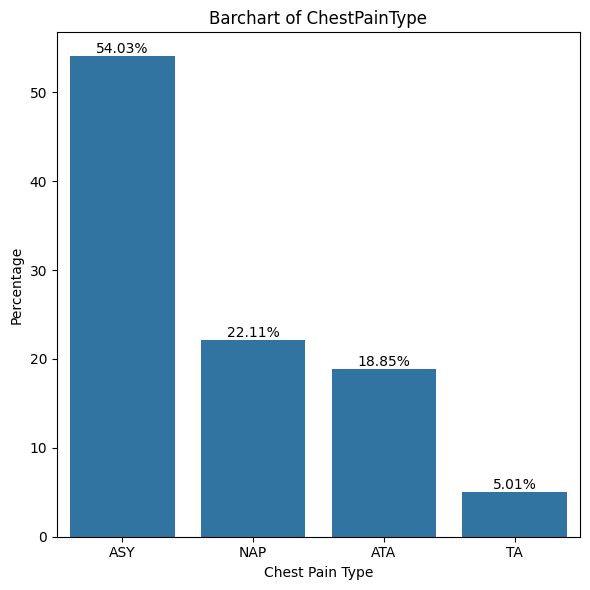

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(1,1, figsize=(6, 6))
sns.countplot( data=df,
              x='ChestPainType',
              ax=axes,
              stat = 'percent',
              order = ['ASY', 'NAP', 'ATA', 'TA'])
# no hue is passed, so this is a single-variable count - the title must not claim a split by Heart Disease
axes.set_title('Barchart of ChestPainType')
axes.set_xlabel('Chest Pain Type')
axes.set_ylabel('Percentage')
axes.bar_label(axes.containers[0], fmt='%.2f%%')

plt.tight_layout()
plt.show()

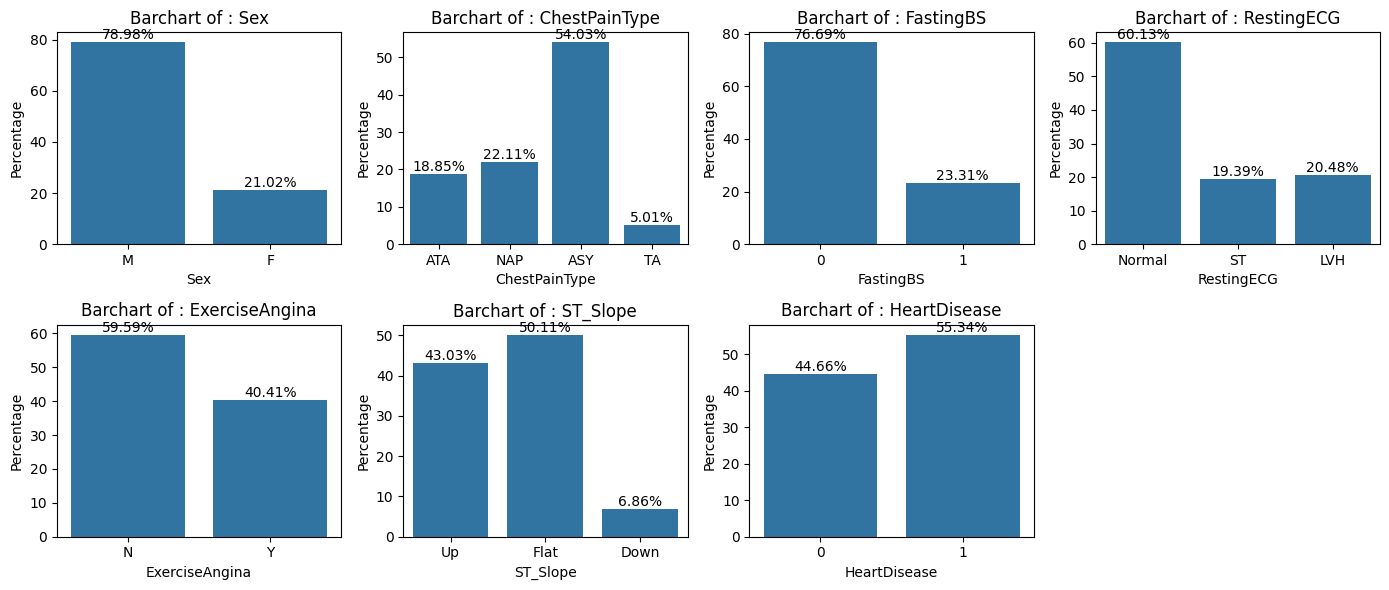

In [10]:
n_cols = len(Qualitative_data.columns)
ncols = 4
nrows = -(-n_cols // ncols)   # ceiling division: derive the grid from the data, so it never leaves stray panels
fig , axes = plt.subplots(nrows, ncols, figsize=(14, 6))
axes = axes.flatten()         # flat indexing is easier to read than axes[i//4, i%4]
for i,col in enumerate(Qualitative_data.columns):
  sns.countplot( df,
              x=col,
              ax=axes[i],
              stat = 'percent',
       )
  axes[i].set_title(f'Barchart of : {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Percentage')
  axes[i].bar_label(axes[i].containers[0], fmt='%.2f%%')
for j in range(n_cols, len(axes)):   # 7 columns in a 2x4 grid leaves 1 frame over - remove it
  fig.delaxes(axes[j])
plt.tight_layout()

- 1.The chest pain category that is most frequent is ASY.
- 2.Heart disease cases aren't balanced across the dataset, as we found out that 55.34% of people have heart disease while 44.66% don't.
- 3.There are 23.31% of patients with elevated fasting blood sugar (`FastingBS` = 1, meaning > 120 mg/dl); the remaining 76.69% are the `FastingBS` = 0 group. This is a diabetes *indicator*, not a diagnosis, so it is a lower bound on how many are actually diabetic.
- 4.There are 40.41% of patients who experience chest pain during exercise.



**C. Quantitative variables:**

- Create statistical summary of column `age`. Describe it briefly.

- Create stistical summary for all other quantitative columns and try to understand those columns.

- Create graphical representation of these quantitative columns to confirm your thoughts from the previous questions and understand them better.

- Are there any columns with outliers? How about weird data points?

In [11]:
df['Age'].describe()

count    918.000000
mean      53.510893
std        9.432617
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: Age, dtype: float64

**Answer1**
`df['Age'].describe()` above covers **all 918 patients**, not only the ones with heart disease. Across the whole dataset the mean age is 53.51 and the median is 54 — the two are almost equal, so the age distribution is close to symmetric with no strong skew. The youngest patient is 28 and the oldest is 77, and half of them fall between 47 (Q1) and 60 (Q3), with a standard deviation of 9.43. So this is a middle-aged-to-older sample, tightly clustered around the mid-fifties.

In [12]:
df.describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364
std,9.432617,18.514154,109.384145,25.460334,1.066570
min,28.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,202.000000,6.200000


**Answer1 (continued) — the other quantitative columns**

- **`RestingBP`** — median 130, mean 132.40, std 18.51. Mean and median are close, so the column is roughly symmetric and tightly packed around a normal resting blood pressure. Its minimum of 0 is not a low reading, it is a recording error.

- **`Cholesterol`** — this is the strange one. Its mean (198.80) is *below* its median (223.00), which is backwards for a lab value like this, and its std of 109.38 is over half the mean. The cell above shows why: 172 rows are recorded as 0, which is 18.7% of the dataset. With those excluded the mean rises to 244.64 and the std falls to 59.15 — so most of that spread was never real variation, it was missing data coded as zero.

- **`MaxHR`** — median 138, mean 136.81, range 60 to 202. Close to symmetric, and the only quantitative column besides `Age` whose minimum and maximum are both physically plausible.

- **`Oldpeak`** — right-skewed: median 0.6 but Q1 is 0, because 40.1% of patients sit at exactly 0. The mean of 0.89 is pulled up by the long right tail out to 6.2. It also has 13 values below 0, down to −2.6, which is a third weird column on top of the two named above.



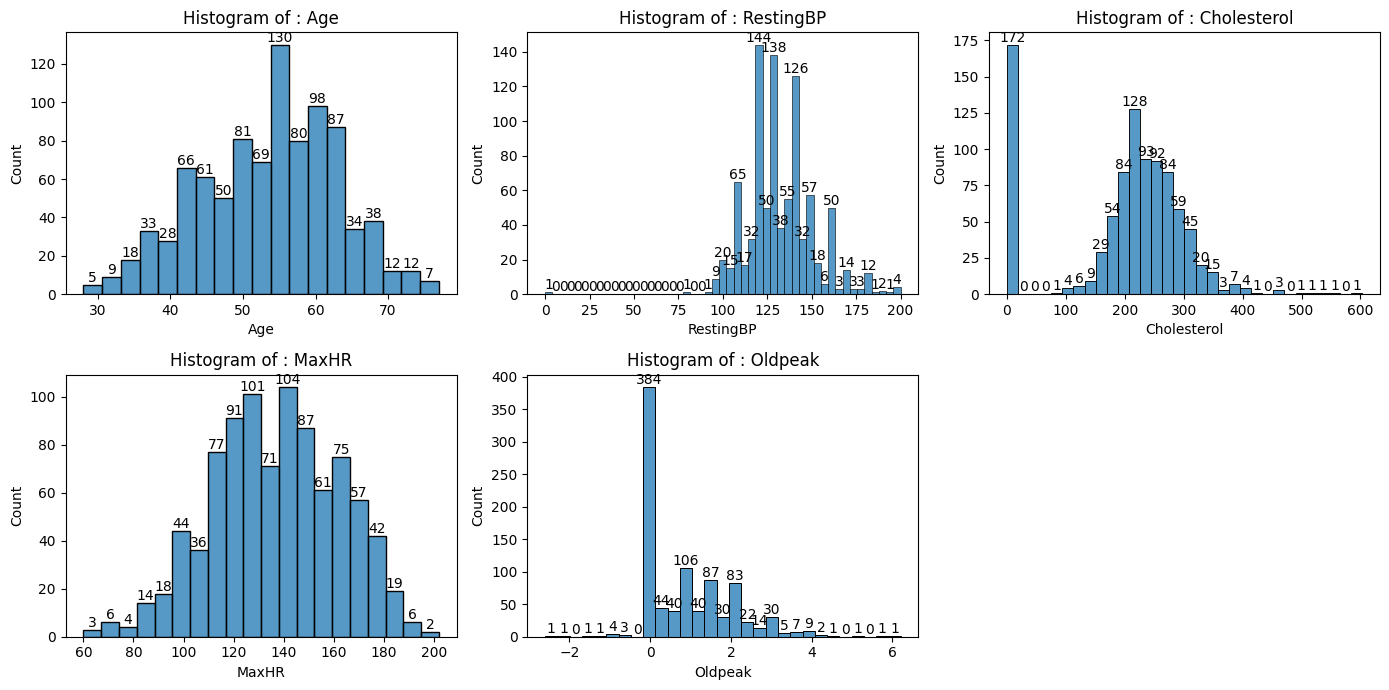

In [13]:
n_cols = len(Quantitative_data.columns)
ncols = 3
nrows = -(-n_cols // ncols)   # ceiling division: 5 columns -> 2 rows, not a hardcoded 2x4
fig , axes = plt.subplots(nrows, ncols, figsize=(14, 7))
axes = axes.flatten()
for i,col in enumerate(Quantitative_data.columns):
  sns.histplot( df,
              x=col,
              ax=axes[i],
       )
  # histplot bins a continuous column, so this is a histogram - a barchart is for categories
  axes[i].set_title(f'Histogram of : {col}')
  axes[i].set_xlabel(col)

  axes[i].bar_label(axes[i].containers[0], )
for j in range(n_cols, len(axes)):   # 5 columns in a 2x3 grid leaves 1 frame over - remove it
  fig.delaxes(axes[j])
plt.tight_layout()

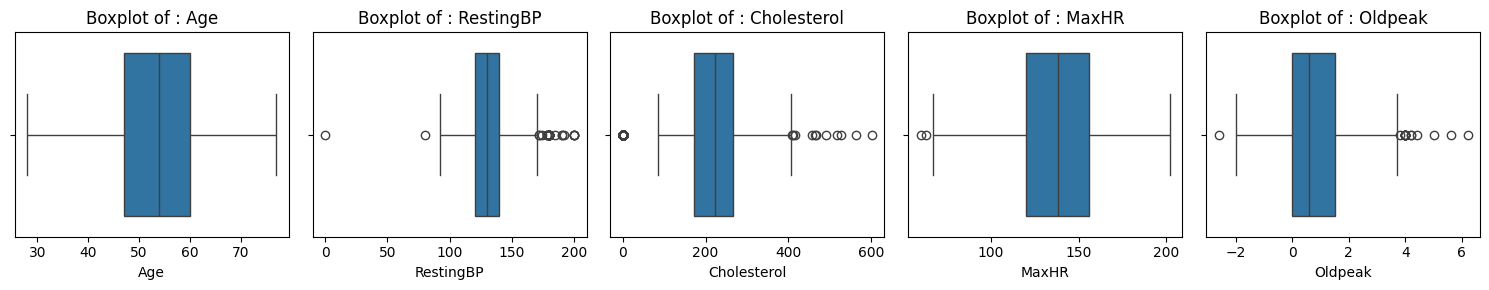

In [14]:
fig , axes = plt.subplots(1,5, figsize=(15, 3))
for i,col in enumerate(Quantitative_data.columns):
  sns.boxplot( df,
              x=col,
                ax=axes[i],)
  axes[i].set_title(f'Boxplot of : {col}')
  axes[i].set_xlabel(col)
plt.tight_layout()

**Answer2:**

Yes, there are some outliers in the quantitative columns, which are `RestingBP`, `Cholesterol`, `MaxHR` and `Oldpeak`.

The weird data points are `RestingBP` and `Cholesterol` that have 0 values, which I found very weird — only dead people can have these types of values. I think there is a mistake from the system, and we as data analysts need to find a solution to wipe out these values.

# **Further Reading**

- `Pandas` python library: [https://pandas.pydata.org/docs/getting_started/index.html#getting-started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started)

- `Pandas Cheatsheet`: [https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)

- `10 Minute to Pandas`: [https://pandas.pydata.org/docs/user_guide/10min.html](https://pandas.pydata.org/docs/user_guide/10min.html)

- `Some Pandas Lession`: [https://www.kaggle.com/learn/pandas](https://pandas.pydata.org/docs/user_guide/10min.html)